<a href="https://colab.research.google.com/github/Nurdaylight/An-Econ-771/blob/main/Plane_experiment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import numpy as np
import matplotlib.pyplot as plt
# 1. Generate synthetic data
np.random.seed(4)

beta=[2,3]

# Generate random X (features)
X = 1 * np.random.rand(3, 1)
x1= np.ones((3, 1))


In [79]:

error = np.random.randn(100, 3)
Y=np.zeros((100,3))
for i in range(100):
  Y[i]= (2+X*3+error[i].reshape(3,-1)).reshape(3)

X=np.hstack( [x1,X])

In [80]:
beta_hat=np.zeros((2,100))
for i in range(100):
  beta_hat[:,i] = ((np.linalg.inv(X.T @ X) @ X.T)@Y[i].reshape(3,1)).T
y_hat=(X@beta_hat).T
y_hat.shape
#Finding the normal vector
cross_prod = np.cross(X[:, 0], X[:, 1])

In [81]:

nA, nB, nC = cross_prod

# --- Plane anchor point (centroid of the data) ---
A0, B0, C0 = y_hat.mean(axis=0)

# Plane constant
D = -(nA*A0 + nB*B0 + nC*C0)

# --- Create plane grid (using A, B, C notation) ---
A_vals = np.linspace(y_hat[:,0].min(), y_hat[:,0].max(), 20)
B_vals = np.linspace(y_hat[:,1].min(), y_hat[:,1].max(), 20)
A, B = np.meshgrid(A_vals, B_vals)

# Solve plane equation for C
C = (-nA*A - nB*B - D) / nC


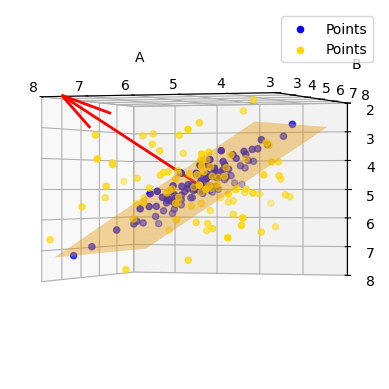

In [42]:

# --- Plot ---
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.dist = 1
# Scatter points
ax.scatter(y_hat[:,0], y_hat[:,1], y_hat[:,2], color='blue', s=20, label='Points')
# Scatter points
ax.scatter(Y[:,0], Y[:,1], Y[:,2], color='gold', s=20, label='Points')

# Plane
ax.plot_surface(A, B, C, alpha=0.4, color='orange')


# View angle
ax.view_init(elev=180, azim=70)
# Normal vector (optional but useful)
ax.quiver(
    A0, B0, C0,
    nA, nB, nC,
    color='red', linewidth=2, length=7
)
ax.set_xlim(3, 8)
ax.set_ylim(3, 8)
ax.set_zlim(2, 8)

ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_zlabel('C')
ax.legend()

plt.show()

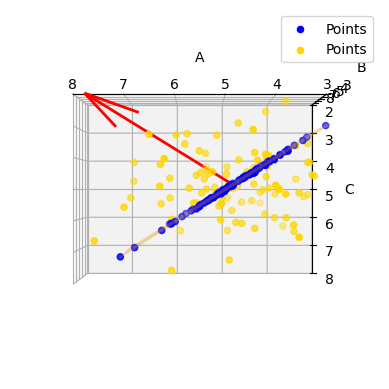

In [43]:
# --- Plot ---
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.dist = 1
# Scatter points
ax.scatter(y_hat[:,0], y_hat[:,1], y_hat[:,2], color='blue', s=20, label='Points')
# Scatter points
ax.scatter(Y[:,0], Y[:,1], Y[:,2], color='gold', s=20, label='Points')

# Plane
ax.plot_surface(A, B, C, alpha=0.4, color='orange')


# View angle
ax.view_init(elev=180, azim=90)
# Normal vector (optional but useful)
ax.quiver(
    A0, B0, C0,
    nA, nB, nC,
    color='red', linewidth=2, length=7
)
ax.set_xlim(3, 8)
ax.set_ylim(3, 8)
ax.set_zlim(2, 8)

ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_zlabel('C')
ax.legend()

plt.show()

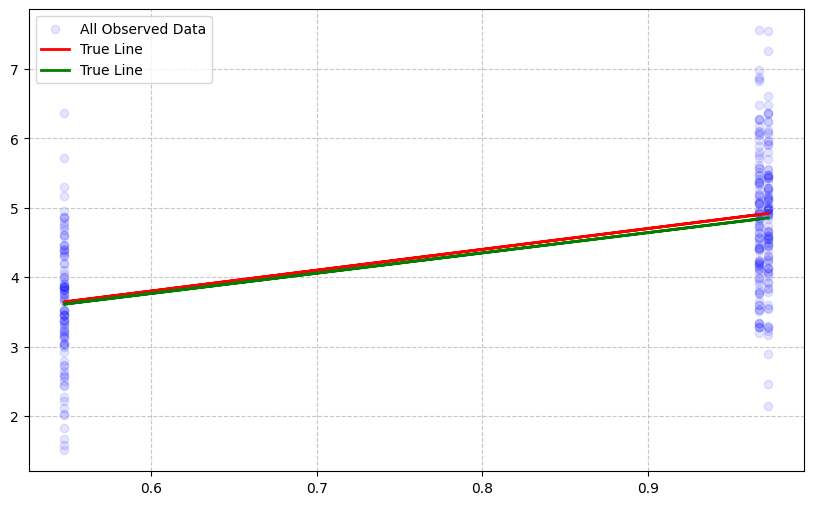

In [44]:
# Calculate predictions using manual beta
y_hat = X @ beta

# Plot the data and the regression line
plt.figure(figsize=(10, 6))

# Plot ALL data points: 100 simulations for each of the 3 X values
# np.tile repeats [x0, x1, x2] 100 times to match Y.flatten()
plt.scatter(np.tile(X[:,1], 100), Y.flatten(), color='blue', alpha=0.1, label='All Observed Data')

plt.plot(X[:,1], beta[0] + beta[1]*X[:,1], color='red', linewidth=2, label='True Line')
plt.plot(X[:,1], beta_hat.mean(1)[0] + beta_hat.mean(1)[1]*X[:,1], color='green', linewidth=2, label='True Line')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [45]:
beta_hat.mean(1)

array([2.01121562, 2.9218792 ])

In [46]:
Y_new=Y.copy()
for i in range(100):

  Y_new[i]= Y[i]+cross_prod*2

In [47]:
beta_hat_new=np.zeros((2,100))
for i in range(100):
  beta_hat_new[:,i] = ((np.linalg.inv(X.T @ X) @ X.T)@Y_new[i].reshape(3,1)).T
y_hat_new=(X@beta_hat).T
y_hat_new.shape


(100, 3)

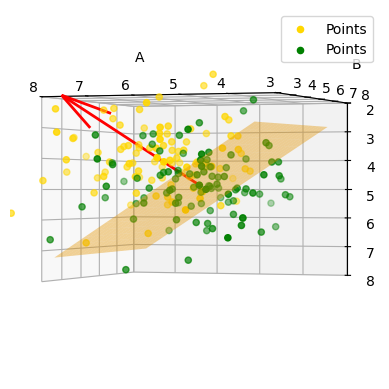

In [48]:

# --- Plot ---
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.dist = 1
# Scatter points
#ax.scatter(y_hat_new[:,0], y_hat_new[:,1], y_hat_new[:,2], color='blue', s=20, label='Points')
# Scatter points
ax.scatter(Y_new[:,0], Y_new[:,1], Y_new[:,2], color='gold', s=20, label='Points')
# Scatter points
ax.scatter(Y[:,0], Y[:,1], Y[:,2], color='green', s=20, label='Points')

# Plane
ax.plot_surface(A, B, C, alpha=0.4, color='orange')


# View angle
ax.view_init(elev=180, azim=70)
# Normal vector (optional but useful)
ax.quiver(
    A0, B0, C0,
    nA, nB, nC,
    color='red', linewidth=2, length=7
)
ax.set_xlim(3, 8)
ax.set_ylim(3, 8)
ax.set_zlim(2, 8)

ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_zlabel('C')
ax.legend()

plt.show()

In [49]:
# BUT WHAT IT MEANS?

# WHAT if there is some noise in null space and some not? Esitmates remain but what does it mean?

# And this vector is data specific. So we can test across data this noise prevalence. We can even pinpoint its direction.

# BUT WHAT IT MEANS?

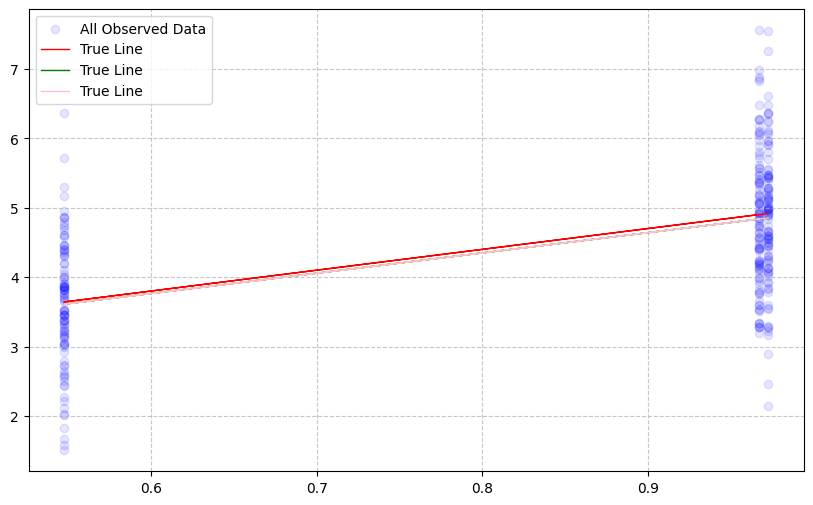

In [50]:
# Calculate predictions using true beta
y_hat_new = X @ beta

# Plot the data and the regression line
plt.figure(figsize=(10, 6))

# Plot ALL data points: 100 simulations for each of the 3 X values
# np.tile repeats [x0, x1, x2] 100 times to match Y.flatten()
plt.scatter(np.tile(X[:,1], 100), Y.flatten(), color='blue', alpha=0.1, label='All Observed Data')

plt.plot(X[:,1], beta[0] + beta[1]*X[:,1], color='red', linewidth=1, label='True Line')
plt.plot(X[:,1], beta_hat.mean(1)[0] + beta_hat.mean(1)[1]*X[:,1], color='green', linewidth=1, label='True Line')
plt.plot(X[:,1], beta_hat_new.mean(1)[0] + beta_hat_new.mean(1)[1]*X[:,1], color='pink', linewidth=1, label='True Line')




plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [51]:
np.allclose(y_hat_new,y_hat)

True

In [52]:
np.allclose(Y_new,Y)

False

In [53]:
Y_new[:3]

array([[6.74546344, 4.70971027, 5.53008351],
       [5.41318176, 3.99661951, 3.77344576],
       [5.26707042, 3.50972204, 3.9996314 ]])

In [54]:
Y[:3]

array([[5.89455922, 4.72101931, 6.36967869],
       [4.56227754, 4.00792856, 4.61304094],
       [4.41616619, 3.52103108, 4.83922658]])

In [55]:
np.allclose(beta_hat,beta_hat_new)

True

In [56]:
error_new=error+cross_prod*200

In [57]:
error.mean()

np.float64(-0.05354512496717395)

In [58]:
error_new.mean()

np.float64(-0.05354512496717229)

In [59]:
cross_prod.mean()

np.float64(0.0)

In [60]:
error.std()

np.float64(0.9436266819024359)

In [61]:
error_new.std()

# Variance increased, but what is meaningful about it?

np.float64(69.02535381334461)

In [62]:
X

array([[1.        , 0.96702984],
       [1.        , 0.54723225],
       [1.        , 0.97268436]])

In [197]:

# Generate random X (features)
X2 = np.array([[0.0],[0.5723225],[0.97268436]])


X2

array([[0.        ],
       [0.5723225 ],
       [0.97268436]])

In [199]:


Y2=np.zeros((100,3))
for i in range(100):
  Y2[i]= (2+X2*3+error[i].reshape(3,-1)).reshape(3)

X2=np.hstack( [x1,X2])

In [200]:
beta_hat2=np.zeros((2,100))
for i in range(100):
  beta_hat2[:,i] = ((np.linalg.inv(X2.T @ X2) @ X2.T)@Y2[i].reshape(3,1)).T
y_hat2=(X2@beta_hat).T
y_hat2.shape
#Finding the normal vector
cross_prod2 = np.cross(X2[:, 0], X2[:, 1])


beta_hat2.var(1)

array([0.73457499, 1.87082446])

In [157]:

nA2, nB2, nC2 = cross_prod2

# --- Plane anchor point (centroid of the data) ---
A02, B02, C02 = y_hat2.mean(axis=0)

# Plane constant
D2 = -(nA2*A02 + nB2*B02 + nC2*C02)

# --- Create plane grid (using A, B, C notation) ---
A_vals2 = np.linspace(y_hat2[:,0].min(), y_hat2[:,0].max(), 20)
B_vals2 = np.linspace(y_hat2[:,1].min(), y_hat2[:,1].max(), 20)
A2, B2 = np.meshgrid(A_vals2, B_vals2)

# Solve plane equation for C
C2 = (-nA2*A2 - nB2*B2 - D2) / nC2


/tmp/ipython-input-859127242.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


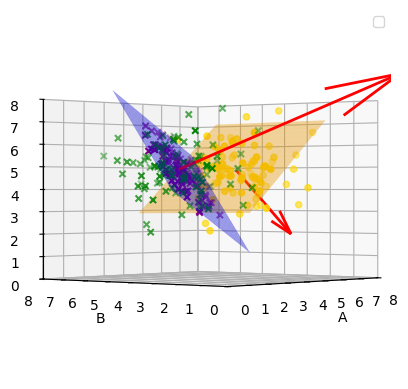

In [158]:

# --- Plot ---
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.dist = 1
# Scatter points
ax.scatter(y_hat2[:,0], y_hat2[:,1], y_hat2[:,2], color='purple', s=20,marker="x")
# Scatter points
ax.scatter(Y2[:,0], Y2[:,1], Y2[:,2], color='green', s=20,marker="x")

# Scatter points
ax.scatter(Y[:,0], Y[:,1], Y[:,2], color='gold')


# Plane
ax.plot_surface(A, B, C, alpha=0.4, color='orange')
# Plane
ax.plot_surface(A2, B2, C2, alpha=0.4, color='blue')

# View angle
ax.view_init(elev=0, azim=220)
# Normal vector (optional but useful)
ax.quiver(
    A0, B0, C0,
    nA, nB, nC,
    color='red', linewidth=2, length=7
)
ax.quiver(
    A02, B02, C02,
    nA2, nB2, nC2,
    color='red', linewidth=2, length=7
)
ax.set_xlim(0, 8)
ax.set_ylim(0, 8)
ax.set_zlim(0, 8)

ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_zlabel('C')
ax.legend()

plt.show()

In [174]:
cross_prod2

array([ 0.        ,  0.89549097, -0.89549097])

In [202]:
X2 = np.array([[0.82723225],[0.81723225],[0.84723225]])

Y2=np.zeros((100,3))
for i in range(100):
  Y2[i]= (2+X2*3+error[i].reshape(3,-1)).reshape(3)

X2=np.hstack( [x1,X2])
beta_hat2=np.zeros((2,100))
for i in range(100):
  beta_hat2[:,i] = ((np.linalg.inv(X2.T @ X2) @ X2.T)@Y2[i].reshape(3,1)).T
y_hat2=(X2@beta_hat2).T
y_hat2.shape
#Finding the normal vector
cross_prod2 = np.cross(X2[:, 0], X2[:, 1])


beta_hat2.var(1)

array([1174.26622567, 1709.63897918])

In [194]:
beta_hat2.shape

(2, 100)

In [203]:

nA2, nB2, nC2 = cross_prod2

# --- Plane anchor point (centroid of the data) ---
A02, B02, C02 = y_hat2.mean(axis=0)

# Plane constant
D2 = -(nA2*A02 + nB2*B02 + nC2*C02)

# --- Create plane grid (using A, B, C notation) ---
A_vals2 = np.linspace(y_hat2[:,0].min(), y_hat2[:,0].max(), 20)
B_vals2 = np.linspace(y_hat2[:,1].min(), y_hat2[:,1].max(), 20)
A2, B2 = np.meshgrid(A_vals2, B_vals2)

# Solve plane equation for C
C2 = (-nA2*A2 - nB2*B2 - D2) / nC2

/tmp/ipython-input-1518713437.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


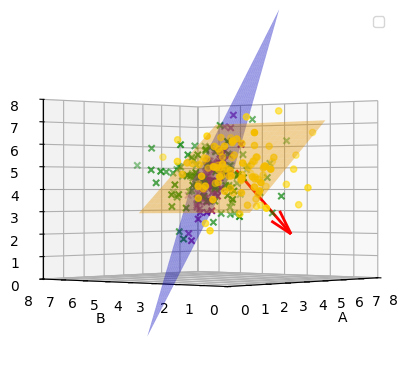

In [204]:
# --- Plot ---
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.dist = 1
# Scatter points
ax.scatter(y_hat2[:,0], y_hat2[:,1], y_hat2[:,2], color='purple', s=20,marker="x")
# Scatter points
ax.scatter(Y2[:,0], Y2[:,1], Y2[:,2], color='green', s=20,marker="x")

# Scatter points
ax.scatter(Y[:,0], Y[:,1], Y[:,2], color='gold')


# Plane
ax.plot_surface(A, B, C, alpha=0.4, color='orange')
# Plane
ax.plot_surface(A2, B2, C2, alpha=0.4, color='blue')

# View angle
ax.view_init(elev=0, azim=220)
# Normal vector (optional but useful)
ax.quiver(
    A0, B0, C0,
    nA, nB, nC,
    color='red', linewidth=2, length=7
)
ax.quiver(
    A02, B02, C02,
    nA2, nB2, nC2,
    color='blue', linewidth=2, length=7
)
ax.set_xlim(0, 8)
ax.set_ylim(0, 8)
ax.set_zlim(0, 8)

ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_zlabel('C')
ax.legend()

plt.show()